# Frameworks, Processes & Logging


## Data Flow: Dataset, DataCollator, DataLoader

In modern pipelines, data moves from raw sources to model-ready tensors through three parts:

### 1. Dataset

**Purpose.** Represents raw data in a structured form and exposes items via indexing.  
**Responsibilities.**

- Reading raw data (files/streams).
- Lightweight preprocessing.
- Returning a single sample (e.g., a PIL image and its label for MNIST).

For MNIST, `torchvision.datasets.MNIST` yields `(PIL.Image, label)`.

### 2. DataCollator

**Purpose.** Takes a **list of samples** and turns it into a **batch** with uniform tensor shapes.  
**Responsibilities.**

- Convert items to tensors.
- Apply **padding/truncation** for variable-length problems (NLP) or **transforms/normalization** for vision.
- Return a **dict of batched tensors** (e.g., `{"pixel_values": Tensor, "labels": Tensor}`).

> Here we deliberately move **normalization** into the collator instead of the `Dataset` transform to demonstrate the pattern (useful when you must apply different policies per dataloader).

### 3. DataLoader

**Purpose.** Iterates over the dataset to provide **batches** during training/eval.  
**Responsibilities.**

- Batching and shuffling.
- Parallel loading with `num_workers`.
- Integration with `collate_fn` (our DataCollator).

During training, a dataloader yields batches like:

```python
for batch in train_loader:
    x, y = batch["pixel_values"], batch["labels"]
    logits = model(x)
    ...
```


torchmetrics==1.8.2 <br>
lightning==2.5.5 <br>
transformers==4.53.3


In [ ]:
import os, math, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


# Reproducibility helpers
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Load MNIST


In [ ]:
# Download MNIST with transform=None (we'll normalize in the collator)
data_root = "../../data"
mnist_train = datasets.MNIST(root=data_root, train=True, download=True, transform=None)
mnist_test = datasets.MNIST(root=data_root, train=False, download=True, transform=None)

len(mnist_train), len(mnist_test), type(mnist_train[0][0]).__name__, mnist_train[0][1]

(60000, 10000, 'Image', 5)

In [3]:
mnist_train[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

In [4]:
mnist_train[0][0]

### Model: MLP

We'll use the exact architecture from the previous lecture.


In [ ]:
import torch.nn as nn


class DeepMLP(nn.Module):
    def __init__(self):
        super(DeepMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 10),
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        return self.layers(x)


model = DeepMLP().to(device)
sum(p.numel() for p in model.parameters()) / 1e6  # ~ 0.5M params

0.577178

### DataCollator for MNIST

- Converts PIL to tensor with `ToTensor()`
- Applies dataset-wise normalization with mean `0.1307`, std `0.3081`
- Returns a dict of batched tensors


In [ ]:
class MNISTCollator:
    def __init__(self):
        self.tf = transforms.Compose(
            [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
        )

    def __call__(self, batch):
        # IMPORTANT: stay on CPU inside workers
        xs, ys = [], []
        for img, y in batch:
            xs.append(self.tf(img))  # CPU [1, 28, 28]
            ys.append(y)
        x = torch.stack(xs, dim=0)  # CPU [B, 1, 28, 28]
        y = torch.tensor(ys, dtype=torch.long)  # CPU
        return {"pixel_values": x, "labels": y}  # no .to(device) here


collator = MNISTCollator()

In [ ]:
num_workers = max(os.cpu_count() - 1, 1)
batch_size = 128

train_loader = DataLoader(
    mnist_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collator,
)
val_loader = DataLoader(
    mnist_test,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collator,
)

# Move to GPU in the main process only (non_blocking pairs with pin_memory=True)
batch = next(iter(train_loader))
x = batch["pixel_values"].to(device, non_blocking=True)
y = batch["labels"].to(device, non_blocking=True)
print(x.shape, y.shape)

torch.Size([128, 1, 28, 28]) torch.Size([128])


## PyTorch Lightning: structure, features & capabilities

**Why Lightning?**

- Boilerplate-free training loops (`training_step`, `validation_step`).
- Built-in logging integration (W&B/TensorBoard/MLflow).
- Callbacks (checkpointing, LR monitor, early stopping).
- Easy scaling: `accelerator="gpu"`, `strategy="ddp"`, `precision=16/32/bf16`.
- Advanced strategies: **FSDP**, **DeepSpeed**, etc.

**High-level API:**

```python
class LitModule(pl.LightningModule):
    def training_step(self, batch, batch_idx): ...
    def validation_step(self, batch, batch_idx): ...
    def configure_optimizers(self): ...
```


In [ ]:
import pytorch_lightning as pl
import torchmetrics


class LitDeepMLP(pl.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = DeepMLP()
        self.criterion = nn.CrossEntropyLoss()
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch["pixel_values"], batch["labels"]
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = logits.argmax(dim=-1)
        self.train_acc.update(preds, y)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        acc = self.train_acc.compute()
        self.log("train_acc", acc, prog_bar=True)
        self.train_acc.reset()

    def validation_step(self, batch, batch_idx):
        x, y = batch["pixel_values"], batch["labels"]
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = logits.argmax(dim=-1)
        self.val_acc.update(preds, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)

    def on_validation_epoch_end(self):
        acc = self.val_acc.compute()
        self.log("val_acc", acc, prog_bar=True)
        self.val_acc.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
        return {"optimizer": optimizer, "lr_scheduler": scheduler}


# Lightning DataModule using our collator
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, data_root="../../data", batch_size=128, num_workers=None):
        super().__init__()
        self.data_root = data_root
        self.batch_size = batch_size
        self.num_workers = num_workers or max(os.cpu_count() - 1, 1)
        self.collator = MNISTCollator()

    def setup(self, stage=None):
        self.train_ds = datasets.MNIST(
            self.data_root, train=True, download=True, transform=None
        )
        self.val_ds = datasets.MNIST(
            self.data_root, train=False, download=True, transform=None
        )

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.batch_size,
            shuffle=True,
            pin_memory=torch.cuda.is_available(),
            collate_fn=self.collator,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds,
            batch_size=self.batch_size,
            shuffle=False,
            pin_memory=torch.cuda.is_available(),
            collate_fn=self.collator,
        )


lit_model = LitDeepMLP(lr=1e-3)
datamodule = MNISTDataModule()

### Lightning Trainer + Logging

We'll use **Weights & Biases** if available; otherwise we fall back to Lightning's default logger.  
You can set offline mode by `WANDB_MODE=offline`.

> Alternatives covered later: **TensorBoard**, **MLflow**.


In [ ]:
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor

use_wandb = True
try:
    import wandb

    wandb_logger = WandbLogger(project="frameworks-lecture", name="deepmlp-lightning")
except Exception as e:
    print("W&B not available, using default logger:", e)
    use_wandb = False
    wandb_logger = None

checkpoint_cb = ModelCheckpoint(
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="deepmlp-{epoch:02d}-{val_acc:.4f}",
)
lr_monitor = LearningRateMonitor(logging_interval="step")

trainer = pl.Trainer(
    max_epochs=5,
    logger=wandb_logger if use_wandb else True,
    callbacks=[checkpoint_cb, lr_monitor],
    accelerator="auto",
    devices=1 if torch.cuda.is_available() else None,
)

trainer.fit(lit_model, datamodule=datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
wandb: Currently logged in as: bazdyrev99 (bazdyrev99-igor-sikorsky-kyiv-polytechnic-institute) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | DeepMLP            | 577 K  | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | train_acc | MulticlassAccuracy | 0      | train
3 | val_acc   | MulticlassAccuracy | 0      | train
---------------------------------------------------------
577 K     Trainable params
0         Non-trainable params
577 K     Total params
2.309     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                           | 0/? [00:00<?, ?it/s]

/home/abazdyrev/anaconda3/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/abazdyrev/anaconda3/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |                                                                  | 0/? [00:00<?, ?it/s]

Validation: |                                                                | 0/? [00:00<?, ?it/s]

Validation: |                                                                | 0/? [00:00<?, ?it/s]

Validation: |                                                                | 0/? [00:00<?, ?it/s]

Validation: |                                                                | 0/? [00:00<?, ?it/s]

Validation: |                                                                | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


## Logging/Tracking Alternatives: Pros & Cons

| Tool                             | Strengths                                                        | Weaknesses                                                                                   | Best for                                  |
| -------------------------------- | ---------------------------------------------------------------- | -------------------------------------------------------------------------------------------- | ----------------------------------------- |
| **Weights & Biases**             | Rich UI, artifacts, sweeps, tables, media logging, team features | Requires account; data leaves your infra unless self-hosted options; vendor lock-in concerns | Research + production experiment tracking |
| **TensorBoard**                  | Ships with PyTorch/TF, easy scalars/images/graphs                | Limited experiment management; harder collaboration; file-based                              | Quick local runs, classic DL workflows    |
| **MLflow**                       | Open-source, self-hostable, model registry, reproducible runs    | UI less polished, media logging basic                                                        | Enterprise/self-hosted MLOps stacks       |
| **CSV/JSON + custom dashboards** | Full control, minimal deps                                       | You must build everything                                                                    | Highly regulated or bespoke infra         |

**TensorBoard snippet (Lightning):**

```python
from pytorch_lightning.loggers import TensorBoardLogger
tb_logger = TensorBoardLogger(save_dir="tb_logs", name="mnist_mlp")
trainer = pl.Trainer(logger=tb_logger, ...)
```

**MLflow snippet (Lightning):**

```python
from pytorch_lightning.loggers import MLFlowLogger
mlf_logger = MLFlowLogger(experiment_name="mnist-mlp", tracking_uri="http://localhost:5000")
trainer = pl.Trainer(logger=mlf_logger, ...)
```


## Training tricks

### Gradient clipping

In many cases, you first compute the norm (typically the L2 norm) of the gradient vector. If this norm exceeds a predefined threshold, the gradients are scaled down proportionally so that their norm is equal to the threshold. Mathematically, if the norm of the gradients $ \|g\| $ is greater than a threshold $ \tau $, the clipped gradients $ g' $ are computed as:

$$
g' = g \times \frac{\tau}{\|g\|}
$$

This ensures that while the direction of the gradient remains unchanged, its magnitude is controlled.

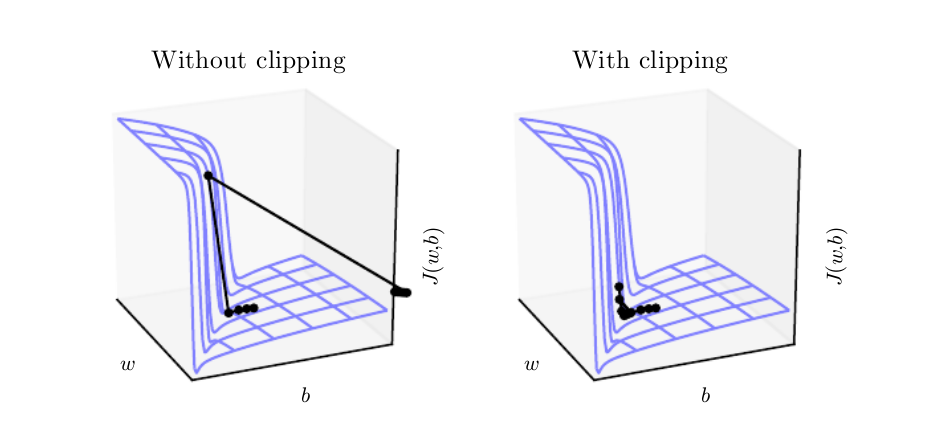

You can check the math details [here](https://neptune.ai/blog/understanding-gradient-clipping-and-how-it-can-fix-exploding-gradients-problem)

```python
trainer = pl.Trainer(
    gradient_clip_val=1.0
)
```

### Gradient accumulation

1. **Accumulate Gradients:**  
   During training, after processing each mini-batch, you compute the gradients but do not immediately update the model parameters. Instead, you add the gradients into a cumulative gradient buffer.

2. **Parameter Update After Several Batches:**  
   Once you have processed a predefined number of mini-batches, say $N$, the accumulated gradients are averaged and used to update the model parameters. Mathematically, if $g_i$ is the gradient from the $i$-th mini-batch, the average gradient is computed as:

   $$
   g_{\text{avg}} = \frac{1}{N} \sum_{i=1}^{N} g_i
   $$

3. **Reset the Gradient Buffer:**  
   After the update, the gradient buffer is reset to zero so that the accumulation process can start over for the next set of mini-batches.

Lightning examples:

```python
trainer = Trainer(accumulate_grad_batches=8) #it will accumulate every 8 batches.
```

```python
from lightning.pytorch.callbacks import GradientAccumulationScheduler

# till 5th epoch, it will accumulate every 8 batches. From 5th epoch
# till 9th epoch it will accumulate every 4 batches and after that no accumulation
accumulator = GradientAccumulationScheduler(scheduling={0: 8, 4: 4, 8: 1})
trainer = Trainer(callbacks=accumulator)
```

## Stochastic Weight Averaging (SWA)

Stochastic Weight Averaging (SWA) is a technique designed to improve the generalization of deep neural networks. Instead of relying solely on the final weights obtained at the end of training, SWA collects and averages weights from multiple points along the training trajectory. This process results in a more robust and smoother model.

During training, the model weights are periodically saved, especially in the later stages. The final SWA weights are computed as the average of these collected weights. Mathematically, if $W_i$ represents the model weights at the $i$-th checkpoint and there are $N$ such checkpoints, then the SWA weights are given by:

$$
W_{\text{swa}} = \frac{1}{N} \sum_{i=1}^{N} W_i
$$

This averaging tends to smooth out the fluctuations and noise present in the individual weight configurations, leading to improved generalization.

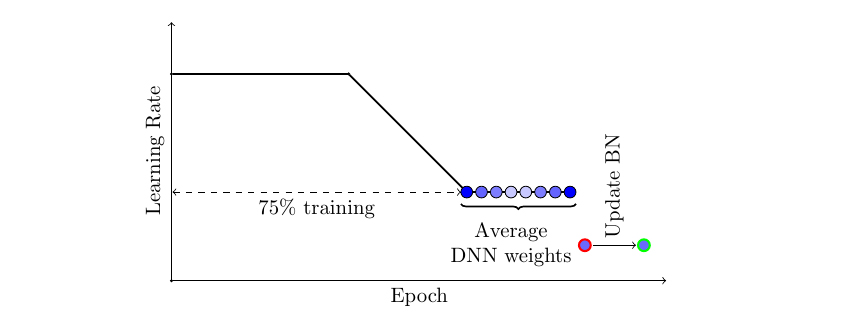

You can check more for [raw torch](https://pytorch.org/blog/pytorch-1.6-now-includes-stochastic-weight-averaging/)
or for [lightning](https://lightning.ai/docs/pytorch/stable/advanced/training_tricks.html)

```python
trainer = Trainer(callbacks=[StochasticWeightAveraging(swa_lrs=1e-2)])
```

## Distributed Data Parallel (DDP) Training

Distributed Data Parallel (DDP) is a strategy in PyTorch for training neural networks across multiple GPUs or nodes by distributing the workload across different processes. Each process handles a subset of the data and maintains a replica of the model. During training, DDP synchronizes gradients across these processes to ensure that each model replica is updated consistently.

- **Process-per-GPU:**  
  DDP spawns one process for each GPU, allowing each GPU to operate independently on its portion of the data.

- **Gradient Synchronization:**  
  After computing gradients for a mini-batch, DDP automatically synchronizes these gradients across all processes using efficient collective communication, ensuring consistent updates.

- **Scalability:**  
  DDP is highly scalable and is especially effective in single-node multi-GPU setups. It can also be extended to multi-node environments with proper configuration.

```python
Trainer(accelerator="gpu", devices=8, strategy="ddp")
```

You can find more details [here](https://lightning.ai/pages/community/tutorial/distributed-training-guide/) and [here](https://lightning.ai/docs/pytorch/stable/accelerators/gpu_intermediate.html)

## Fully Sharded Data Parallel (FSDP) Training

Fully Sharded Data Parallel (FSDP) is a distributed training technique in PyTorch designed to optimize memory usage when training large models. By sharding model parameters, gradients, and optimizer states across multiple GPUs, FSDP allows you to train models that might not otherwise fit into a single GPU's memory.

- **Parameter Sharding:**  
  FSDP divides the model parameters among available GPUs. Each GPU only holds a fraction of the full model, reducing memory requirements.

- **Gradient and Optimizer State Sharding:**  
  In addition to parameters, gradients and optimizer states are also sharded. This further reduces memory overhead during training.

More details about [fsdp training](https://lightning.ai/docs/pytorch/stable/advanced/model_parallel/fsdp.html)

```python
from lightning.pytorch.strategies import FSDPStrategy
strategy = FSDPStrategy(
    # Default: Shard weights, gradients, optimizer state (1 + 2 + 3)
    sharding_strategy="FULL_SHARD",
    # Shard gradients, optimizer state (2 + 3)
    sharding_strategy="SHARD_GRAD_OP",
    # Don't shard anything (similar to DDP)
    sharding_strategy="NO_SHARD",
)
trainer = L.Trainer(..., strategy=strategy)
```

## Mixed Precision Training

Mixed precision training leverages both 16-bit and 32-bit floating point computations to reduce memory usage and speed up training, without sacrificing model accuracy. PyTorch Lightning makes it easy to enable mixed precision by simply specifying a precision level when creating the `Trainer`.

- **Reduced Memory Footprint:**  
  Using 16-bit precision for parts of the computation allows you to train larger models or use larger batch sizes.
- **Faster Training:**  
  Some of the hardware optimized for lower precision arithmetic (like NVIDIA's Tensor Cores) can execute 16-bit operations faster, improving overall training speed (e.g. A100/H100 with bf16 format).
- **Maintained Accuracy:**  
  Automatic loss scaling ensures numerical stability, so model accuracy is maintained.

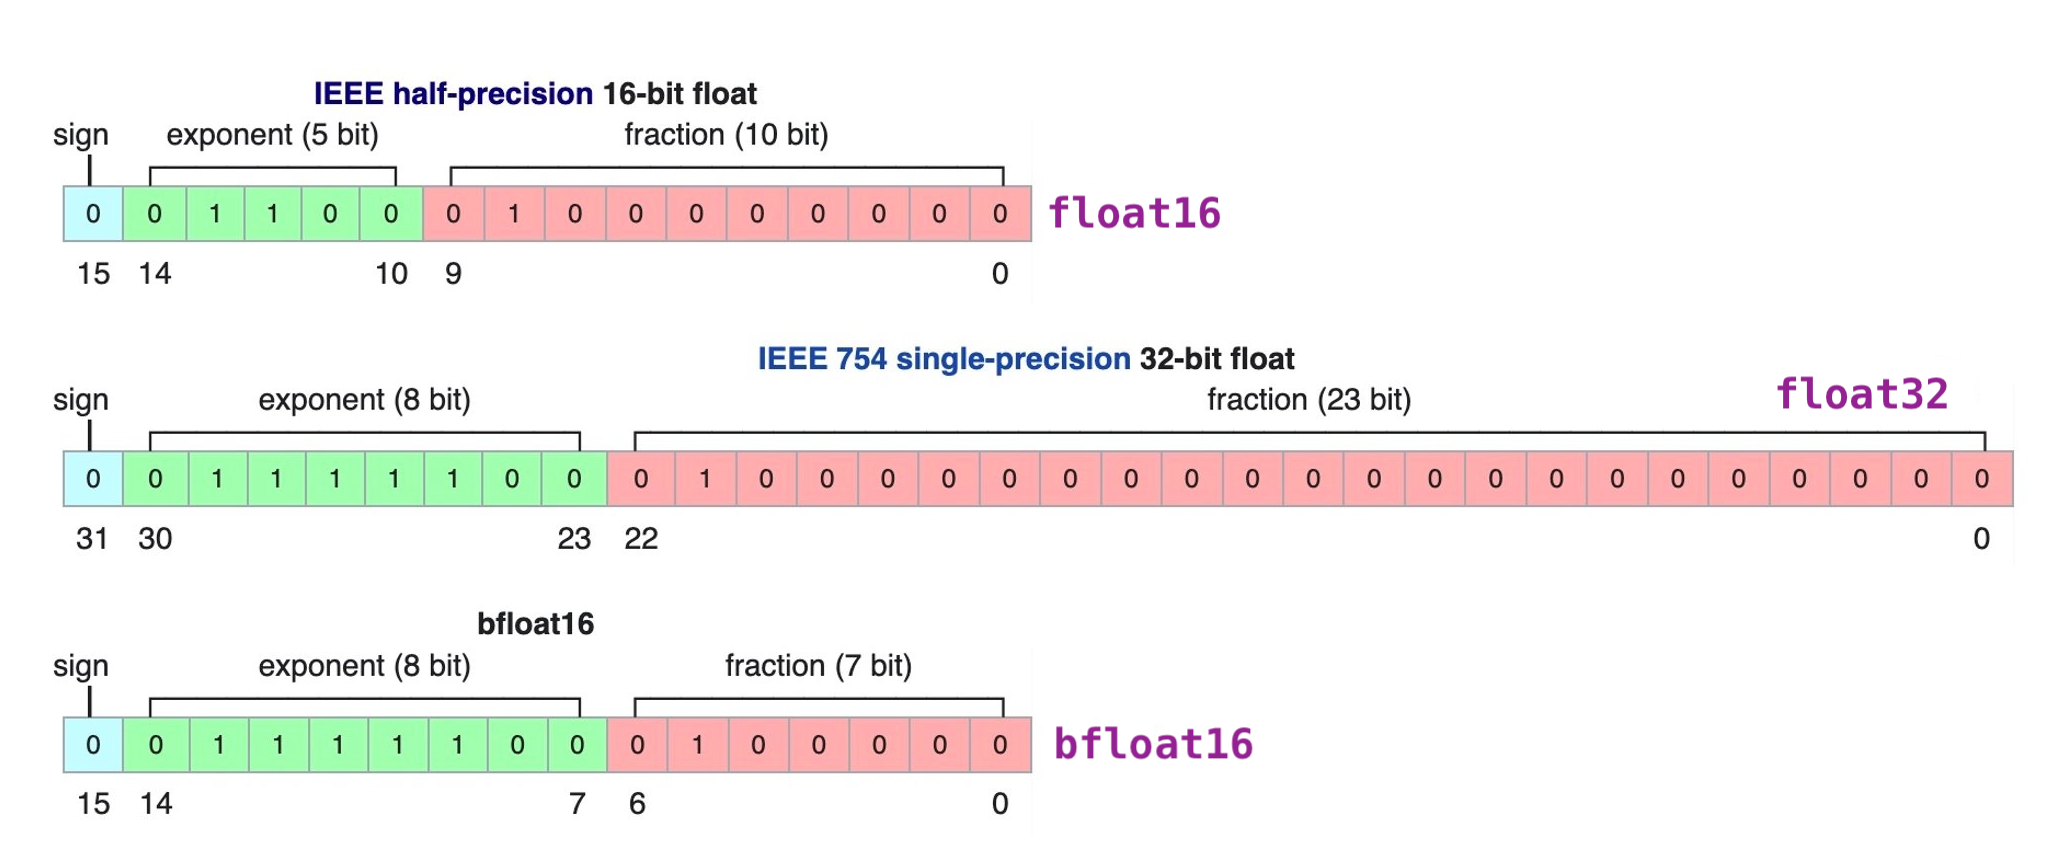

FP16:

- A trend in DL towards using FP16 instead of FP32 because lower precision calculations seem to be not critical for neural networks. Additional precision gives nothing, while being slower, takes more memory and reduces speed of communication.
- Can be used for training, typically using mixed-precision training (TensorFlow/PyTorch).
- Can be used for post-training quantization for faster inference (TensorFlow Lite). Other formats in use for post-training quantization are integer INT8 (8-bit integer), INT4 (4 bits) and even INT1 (a binary value).

BF16:

- Seems to be replacing FP16 right now. Unlike FP16, which typically requires special handling via techniques such as loss scaling, BF16 comes close to being a drop-in replacement for FP32 when training and running deep neural networks.
- GPU: Supported in NVIDIA A100/H100.

```python
Trainer(..., precision=16)
```

or

```python
Trainer(..., precision="bf16")
```


# Huggingface alternative approach


In [10]:
import os, torch, numpy as np
from dataclasses import dataclass
from typing import Dict, List, Tuple, Any, Optional

import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from transformers import Trainer, TrainingArguments
from transformers.trainer_utils import EvalPrediction
from transformers.utils import logging

logger = logging.get_logger(__name__)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# HF-friendly wrapper returning loss + logits


class DeepMLPForImageClassification(nn.Module):
    def __init__(self, num_labels: int = 10):
        super().__init__()
        self.num_labels = num_labels
        self.model = DeepMLP()
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(
        self,
        pixel_values: Optional[torch.Tensor] = None,
        labels: Optional[torch.Tensor] = None,
        **kwargs,
    ):
        logits = self.model(pixel_values)  # pixel_values: [B,1,28,28]
        loss = None
        if labels is not None:
            loss = self.loss_fn(logits, labels)
        return {"loss": loss, "logits": logits}


model = DeepMLPForImageClassification(num_labels=10)
model

DeepMLPForImageClassification(
  (model): DeepMLP(
    (layers): Sequential(
      (0): Linear(in_features=784, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): ReLU()
      (6): Linear(in_features=128, out_features=64, bias=True)
      (7): ReLU()
      (8): Linear(in_features=64, out_features=32, bias=True)
      (9): ReLU()
      (10): Linear(in_features=32, out_features=16, bias=True)
      (11): ReLU()
      (12): Linear(in_features=16, out_features=10, bias=True)
    )
  )
  (loss_fn): CrossEntropyLoss()
)

In [12]:
def compute_metrics(eval_pred: EvalPrediction) -> Dict[str, float]:
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = (preds == labels).mean().item()

    # top-3
    top3 = np.argsort(-logits, axis=1)[:, :3]
    top3_hit = (top3 == labels[:, None]).any(axis=1).mean().item()
    return {"accuracy": acc, "top3": top3_hit}

In [ ]:
import wandb

# Initialize with team/entity

wandb.init(project="frameworks-lecture-hf", name="mnist-mlp", reinit="create_new")

In [ ]:
num_workers = max(os.cpu_count() - 1, 1)
batch_size = 128


training_args = TrainingArguments(
    output_dir="./deepmlp-trainer",
    report_to="wandb",
    run_name="deepmlp-mnist-trainer",
    seed=42,
    # Dataloading
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    dataloader_num_workers=num_workers,
    dataloader_pin_memory=torch.cuda.is_available(),
    # Train/eval cadence & logging
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    # Optim & scheduler
    learning_rate=1e-3,
    weight_decay=0.0,
    lr_scheduler_type="cosine",
    warmup_ratio=0.0,
    optim="adamw_torch",
    # Device
    bf16=False,
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=mnist_train,
    eval_dataset=mnist_test,
    data_collator=collator,  # keeps CPU transforms, no GPU work in workers
    compute_metrics=compute_metrics,  # accuracy + top3
)

In [16]:
train_result = trainer.train()
metrics = trainer.evaluate()

Epoch,Training Loss,Validation Loss,Accuracy,Top3
1,0.204500,0.183435,0.950200,0.989200
2,0.104400,0.102507,0.970400,0.995400
3,0.058400,0.085218,0.976000,0.996800
4,0.033100,0.074532,0.980100,0.996900
5,0.020200,0.071952,0.980300,0.996900


In [17]:
metrics

{'eval_loss': 0.07195203006267548,
 'eval_accuracy': 0.9803,
 'eval_top3': 0.9969,
 'eval_runtime': 0.8272,
 'eval_samples_per_second': 12088.896,
 'eval_steps_per_second': 95.502,
 'epoch': 5.0}